# Segmentación y visualización con paletas de color

**Trabajo práctico — Unidad 2 · Fundamentos del Procesamiento Digital de Imágenes**

El resultado de un proceso de segmentación o análisis a menudo es una **imagen monocanal** (una máscara, un mapa de probabilidad, un mapa de distancia). La forma en que visualizamos ese resultado es crítica para su correcta interpretación. Estas herramientas también se usan durante el proceso de análisis de una imagen a color.

## Tareas y recorrido

| # | Bloque | Tarea de la consigna |
|---|--------|----------------------|
| 1 | Contraste de la imagen | Elegir imagen a color con bajo contraste (histograma + **desviación estándar**) |
| 2 | Umbralización no binaria | Umbralizar directamente sobre Gris (Y) manteniendo los valores continuos (`A Zero` + 2 variantes) |
| 3 | Ecualización | Ecualizar el resultado monocanal y comparar con estiramiento y ecualización adaptativa (ejemplo del profe) |
| 4 | Paletas de color | Visualizar con `gray`, `viridis`, `plasma`, `hot`, `cividis` |
| 5 | Perfil de luminancia | Analizar por qué aparecen "bandas" en algunas paletas |
| 6 | Precisión | Evaluar la precisión de la segmentación lograda |
| 7 | Preguntas | Respuestas a las preguntas de la consigna |

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

RUTA_IMAGEN = 'gorra.jpeg'

bgr = cv2.imread(RUTA_IMAGEN)
if bgr is None:
    raise FileNotFoundError(
        f'No se pudo cargar "{RUTA_IMAGEN}". Ejecutá el notebook desde la carpeta que contiene la imagen.'
    )

img = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
gris = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

print(f'Imagen cargada: {img.shape[1]}x{img.shape[0]} px | {img.shape[2]} canales | dtype={img.dtype}')


def mostrar_imagen(im, titulo='', cmap=None, vmin=0, vmax=255, ax=None):
    if ax is None:
        _, ax = plt.subplots(figsize=(5, 4))
    salida = ax.imshow(im, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(titulo, fontsize=10)
    ax.axis('off')
    return salida

Imagen cargada: 3060x3060 px | 3 canales | dtype=uint8


## Bloque 1 — Selección de imagen y nivel de contraste

Para afirmar que el contraste es bajo en la imagen elegida **no alcanza con mirarla**: se usan dos herramientas

1. el **histograma** — forma, concentración de valores y rango efectivo;
2. la **desviación estándar** (σ) de los niveles — mide la dispersión global de intensidades: a menor σ, menor contraste. Se acompaña del **contraste RMS** = σ / media, que normaliza por el brillo medio de la imagen.

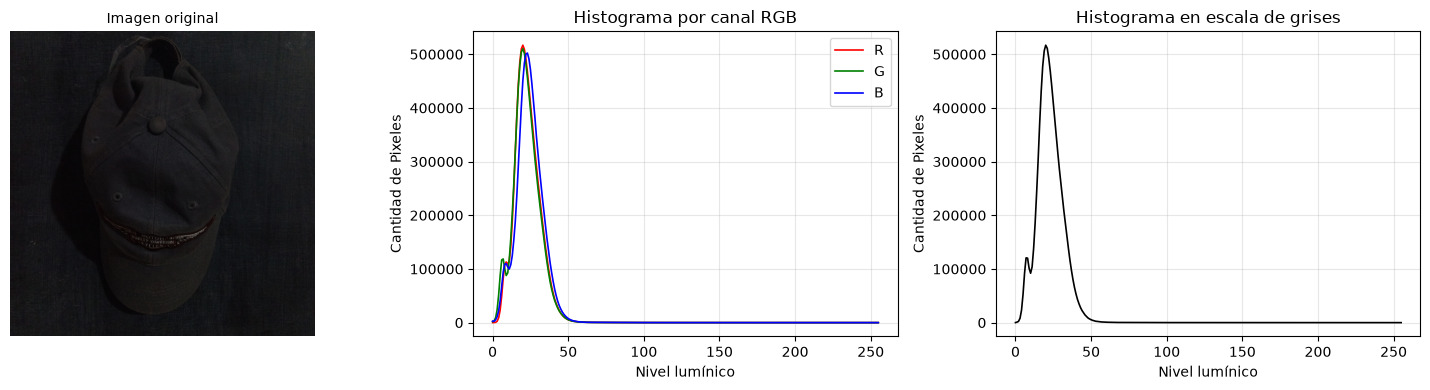

In [2]:
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

mostrar_imagen(img, 'Imagen original', ax=axs[0])

for nombre, i, color in [('R', 0, 'red'), ('G', 1, 'green'), ('B', 2, 'blue')]:
    h = cv2.calcHist([img], [i], None, [256], [0, 256])
    axs[1].plot(h, color=color, label=nombre, linewidth=1.2)
axs[1].set_title('Histograma por canal RGB')
axs[1].set_xlabel('Nivel lumínico')
axs[1].set_ylabel('Cantidad de Pixeles')
axs[1].legend()
axs[1].grid(True, alpha=0.3)

h_gris = cv2.calcHist([gris], [0], None, [256], [0, 256])
axs[2].plot(h_gris, color='black', linewidth=1.2)
axs[2].set_title('Histograma en escala de grises')
axs[2].set_xlabel('Nivel lumínico')
axs[2].set_ylabel('Cantidad de Pixeles')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
def metricas_contraste(datos, nombre):
    d = datos.astype(np.float64)
    media, sigma = d.mean(), d.std()
    rms = sigma / media
    p1, p99 = np.percentile(d, [1, 99])
    print(f'{nombre:>32s} | media={media:6.2f} | sigma={sigma:6.2f} | RMS={rms:5.3f} '
          f'| p1={p1:5.1f} | p99={p99:5.1f} | ancho p1-p99={p99 - p1:6.1f}')


print('--- Métricas de contraste (sin normalizar: se mide la imagen tal cual) ---')
metricas_contraste(gris, 'Gris / luminancia (Y)')

p1, p99 = np.percentile(gris, [1, 99])
print(f'\nRango efectivo p1..p99: [{p1:.0f}, {p99:.0f}] -> uso del rango de 8 bits: {(p99 - p1) / 255:.0%}')
print(f'Maximo global: {gris.max()}')

--- Métricas de contraste (sin normalizar: se mide la imagen tal cual) ---
           Gris / luminancia (Y) | media= 22.76 | sigma=  8.45 | RMS=0.371 | p1=  6.0 | p99= 45.0 | ancho p1-p99=  39.0

Rango efectivo p1..p99: [6, 45] -> uso del rango de 8 bits: 15%
Maximo global: 187


## Bloque 2 — Umbralización sin binarizar (valores continuos) sobre Gris (Y)

Se utiliza directamente el espacio monocanal **Gris (Y)** obtenido a partir de la conversión estándar de luminancia de la imagen a color (`cv2.cvtColor(..., COLOR_RGB2GRAY)`).

La consigna pide umbralizar **manteniendo los valores continuos**. De los analizados por la catedra en *Procesamiento Interactivo* (`Binario`, `Binario Invertido`, `A Zero`, `A Zero Invertido`, `Otsu`), los únicos que **no** binarizan son `A Zero` y `A Zero Invertido`.

| Método | Regla | Efecto |
|---|---|---|
| **A Zero** (`THRESH_TOZERO`) | `salida = x  si x > T` ; `0` si no | Apaga lo más oscuro que T; lo demás conserva **su valor original** |
| **A Zero Invertido** (`THRESH_TOZERO_INV`) | `salida = x  si x <= T` ; `0` si no | Apaga lo más claro que T; conserva lo oscuro |
| **Rampa suave** (custom) | `salida = x · clip((x − t1)/(t2 − t1), 0, 1)` | Cero bajo t1, transición **gradual** entre t1 y t2, valor original sobre t2 |

Con `A Zero` y `A Zero Invertido` con el mismo T se cumple exactamente `A Zero + A Zero Invertido == canal original` (se verifica en el código).

**Valores fijados:** `T` se calcula automáticamente como **Otsu sobre Gris (Y) redondeado al múltiplo de 5** (regla reproducible: se recalcula solo al cambiar de imagen y el valor impreso queda en la salida), y la rampa se centra en ese T (`t1 = T − 10 … t2 = T + 15`). El explorador interactivo permite mover el umbral a mano para entender qué hace cada tipo de umbral antes de fijar el valor.

Otsu sobre Gris (Y) = 24 -> T elegido (multiplo de 5 mas proximo) = 25 | rampa t1=15..t2=40


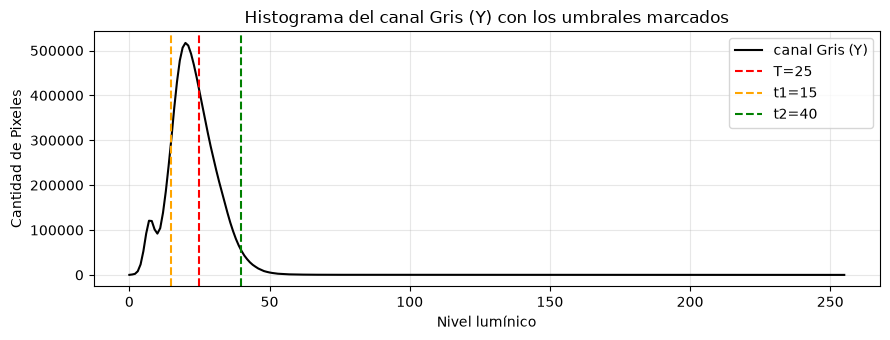

In [4]:
CANAL_ELEGIDO = 'Gris (Y)'
canal = gris


def umbralizar(canal_, t, tipo, ancho=25):
    if tipo == 'A Zero':
        return cv2.threshold(canal_, t, 255, cv2.THRESH_TOZERO)[1]
    if tipo == 'A Zero Invertido':
        return cv2.threshold(canal_, t, 255, cv2.THRESH_TOZERO_INV)[1]
    if tipo == 'Rampa suave':
        t1 = float(t)
        t2 = min(255.0, t1 + ancho)
        x = canal_.astype(np.float32)
        rampa = np.clip((x - t1) / max(t2 - t1, 1e-6), 0.0, 1.0)
        return np.clip(rampa * x, 0, 255).astype(np.uint8)
    raise ValueError(f'Tipo desconocido: {tipo}')


t_otsu_base, _ = cv2.threshold(canal, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
T_ELEGIDO = int(round(float(t_otsu_base) / 5) * 5)
T1_RAMPA, T2_RAMPA = max(0, T_ELEGIDO - 10), min(255, T_ELEGIDO + 15)
print(f'Otsu sobre {CANAL_ELEGIDO} = {t_otsu_base:.0f} -> T elegido (multiplo de 5 mas proximo) = {T_ELEGIDO} '
      f'| rampa t1={T1_RAMPA}..t2={T2_RAMPA}')

fig, ax = plt.subplots(figsize=(9, 3.5))
ax.plot(cv2.calcHist([canal], [0], None, [256], [0, 256]), color='black', label=f'canal {CANAL_ELEGIDO}')
for valor, color, nombre in [(T_ELEGIDO, 'red', f'T={T_ELEGIDO}'),
                             (T1_RAMPA, 'orange', f't1={T1_RAMPA}'),
                             (T2_RAMPA, 'green', f't2={T2_RAMPA}')]:
    ax.axvline(valor, color=color, linestyle='--', label=nombre)
ax.set_title(f'Histograma del canal {CANAL_ELEGIDO} con los umbrales marcados')
ax.set_xlabel('Nivel lumínico')
ax.set_ylabel('Cantidad de Pixeles')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
from ipywidgets import interact, IntSlider, Dropdown


def explorar_umbral(t, ancho, tipo):
    res = umbralizar(canal, t, tipo, ancho=ancho)
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    mostrar_imagen(canal, f'Canal {CANAL_ELEGIDO}', cmap='gray', ax=axs[0])
    mostrar_imagen(res, f'{tipo} — t={t}, ancho={ancho}', cmap='gray', ax=axs[1])
    plt.tight_layout()
    plt.show()
    print(f'valores distintos: {np.unique(res).size} | % en 0: {(res == 0).mean():.1%} | media: {res.mean():.1f}')


interact(explorar_umbral,
         t=IntSlider(value=T_ELEGIDO, min=0, max=255, step=1, description='Umbral'),
         ancho=IntSlider(value=25, min=1, max=100, step=1, description='Ancho rampa'),
         tipo=Dropdown(options=['A Zero Invertido', 'A Zero', 'Rampa suave'],
                       value='A Zero Invertido', description='Tipo'));

interactive(children=(IntSlider(value=25, description='Umbral', max=255), IntSlider(value=25, description='Anc…

A Zero Invertido (T=25)            | valores distintos=  26 | % en 0= 33.6% | media=  12.0
A Zero (T=25)                      | valores distintos= 159 | % en 0= 66.4% | media=  10.7
Rampa suave (15..40)               | valores distintos= 168 | % en 0= 20.9% | media=   9.5


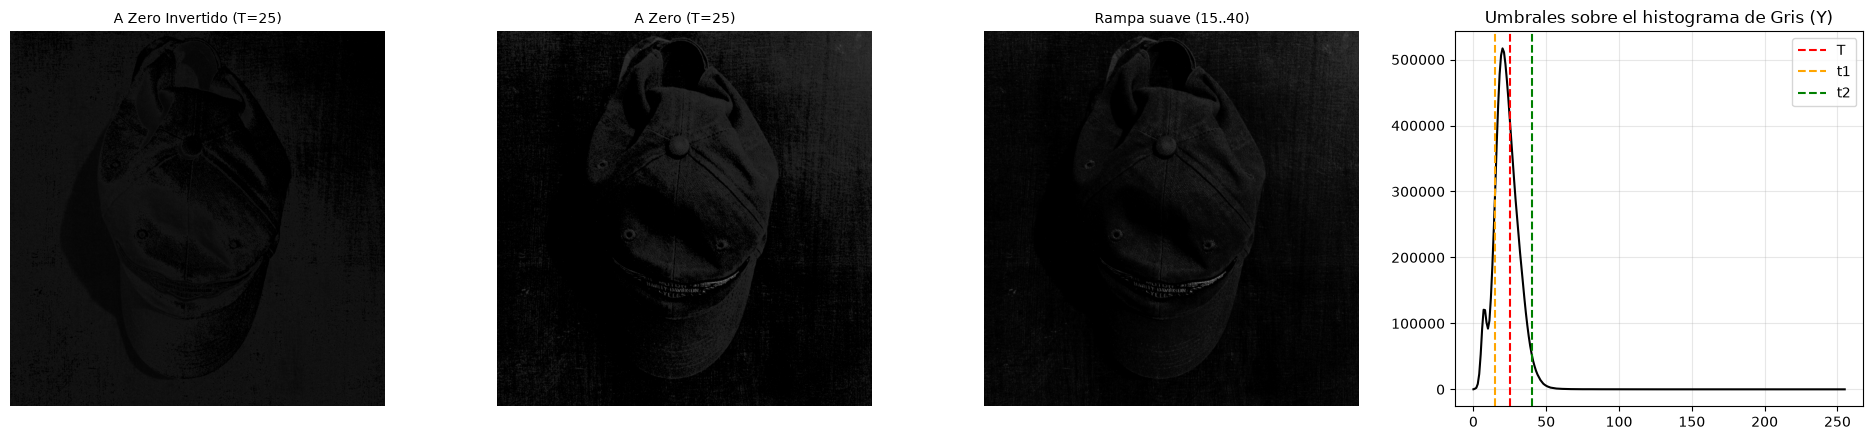


A Zero + A Zero Invertido (mismo T) == canal original: True


In [6]:
resultados = {
    f'A Zero Invertido (T={T_ELEGIDO})': umbralizar(canal, T_ELEGIDO, 'A Zero Invertido'),
    f'A Zero (T={T_ELEGIDO})': umbralizar(canal, T_ELEGIDO, 'A Zero'),
    f'Rampa suave ({T1_RAMPA}..{T2_RAMPA})': umbralizar(canal, T1_RAMPA, 'Rampa suave',
                                                         ancho=T2_RAMPA - T1_RAMPA),
}

fig, axs = plt.subplots(1, 4, figsize=(19, 4.5))
for ax, (titulo, im) in zip(axs[:3], resultados.items()):
    mostrar_imagen(im, titulo, cmap='gray', ax=ax)
    print(f'{titulo:34s} | valores distintos={np.unique(im).size:4d} | '
          f'% en 0={(im == 0).mean():6.1%} | media={im.mean():6.1f}')

axs[3].plot(cv2.calcHist([canal], [0], None, [256], [0, 256]), color='black')
for valor, color, nombre in [(T_ELEGIDO, 'red', 'T'), (T1_RAMPA, 'orange', 't1'), (T2_RAMPA, 'green', 't2')]:
    axs[3].axvline(valor, color=color, linestyle='--', label=nombre)
axs[3].set_title(f'Umbrales sobre el histograma de {CANAL_ELEGIDO}')
axs[3].legend()
axs[3].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('G:/Other computers/notas_unam/UNAM FACULTAD/5to Anio/IC527 - Fundamentos del Procesamiento Digitial de Imagenes/unidad 2/Informes_FDPI/img/ejercicio4/umbralizacion.png', bbox_inches='tight')
plt.show()

suma = resultados[f'A Zero (T={T_ELEGIDO})'].astype(np.int16) + resultados[f'A Zero Invertido (T={T_ELEGIDO})'].astype(np.int16)
print('\nA Zero + A Zero Invertido (mismo T) == canal original:', np.array_equal(suma, canal.astype(np.int16)))

**Conclusión — Bloque 2.** La segmentación principal es **`A Zero Invertido`** sobre el canal **Gris (Y)** con umbral fijo **T = Otsu sobre Gris redondeado al múltiplo de 5** (impreso arriba; regla automática y reproducible: si cambia la imagen, T se recalcula y la salida muestra el nuevo valor). Se elige Invertido porque lo que se quiere aislar es la zona **oscura** del histograma: se conserva el rango `[0, T]` con sus valores originales y se apaga la zona clara; con `A Zero` (regla opuesta) el mismo T apagaría exactamente lo que interesa. La **rampa suave** queda como variante de transición gradual (atenúa en vez de cortar en seco) y `A Zero` como contraprueba: las tres se ven en la misma figura con sus métricas.

Se descartan `Binario`/`Binario Invertido` (binarizan: pierden los valores continuos que la consigna pide conservar) y usar `Otsu` como resultado (devuelve una máscara dura sin valores intermedios: se reserva como referencia automática del bloque de precisión). Criterio: **visual + métrico** — exploración con el widget interactivo, % de píxeles conservados/suprimidos impreso, y la identidad `A Zero + A Zero Invertido == canal original` verificada en el código.

## Bloque 3 — Ecualización del histograma

Se ecualiza el resultado monocanal de la umbralización elegida (`A Zero Invertido`), siguiendo la estructura del ejemplo del profesor (*Ecualización_Adaptativa.ipynb*): las tres técnicas de mejora de contraste se aplican al **mismo** resultado y se comparan con imagen + histograma + histograma acumulativo (CDF).

**Repaso (del ejemplo del profe):**

- El **estiramiento de contraste** expande el rango de intensidades mapeando los percentiles extremos (p2, p98) al rango completo con `exposure.rescale_intensity`.
- La **ecualización global** redistribuye las intensidades para generar un histograma uniforme que cubra todo el rango, con `exposure.equalize_hist`.
- La **ecualización adaptativa** aplica la ecualización localmente en zonas pequeñas de la imagen con `exposure.equalize_adapthist` (límite de recorte `clip_limit`): así aumenta el contraste local sin afectar regiones que ya tienen buen contraste.

**Detalle de ingeniería:** la máscara de ceros de la umbralización **debe preservarse** — los píxeles en 0 siguen en 0: no forman parte del objeto y la ecualización no debe "inventarles" valor.

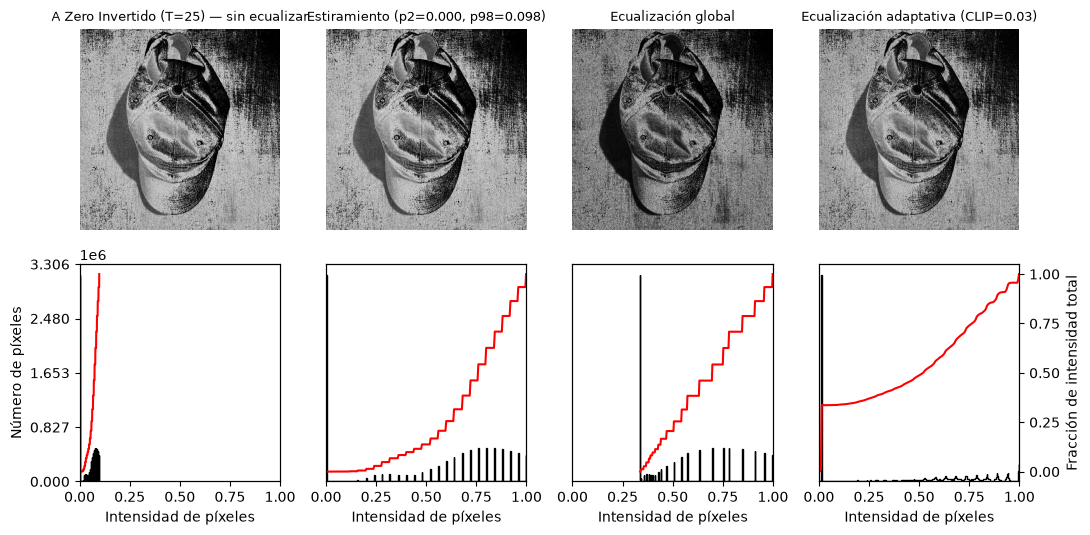

In [7]:
from skimage import exposure


def plot_img_and_hist(image, axes, bins=256):
    ax_img, ax_hist = axes
    ax_cdf = ax_hist.twinx()

    ax_img.imshow(image, cmap=plt.cm.gray)
    ax_img.set_axis_off()

    ax_hist.hist(image.ravel(), bins=bins, histtype='step', color='black')
    ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
    ax_hist.set_xlabel('Intensidad de píxeles')
    ax_hist.set_xlim(0, 1)
    ax_hist.set_yticks([])

    img_cdf, bins = exposure.cumulative_distribution(image, bins)
    ax_cdf.plot(bins, img_cdf, 'r')
    ax_cdf.set_yticks([])

    return ax_img, ax_hist, ax_cdf


resultado_umbral = resultados[f'A Zero Invertido (T={T_ELEGIDO})']
img01 = resultado_umbral.astype(np.float32) / 255

# Estiramiento de contraste: percentiles p2 y p98, igual que el profe
p2, p98 = np.percentile(img01, (2, 98))
img_rescale = exposure.rescale_intensity(img01, in_range=(p2, p98))

# Ecualizacion global
img_eq = exposure.equalize_hist(img01)

# Ecualizacion adaptativa (CLAHE) con limite de recorte
CLIP = 0.03
img_adapteq = exposure.equalize_adapthist(img01, clip_limit=CLIP)

fig = plt.figure(figsize=(11, 5.5))
axes = np.zeros((2, 4), dtype=object)
axes[0, 0] = fig.add_subplot(2, 4, 1)
for i in range(1, 4):
    axes[0, i] = fig.add_subplot(2, 4, 1 + i, sharex=axes[0, 0], sharey=axes[0, 0])
for i in range(0, 4):
    axes[1, i] = fig.add_subplot(2, 4, 5 + i)

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img01, axes[:, 0])
ax_img.set_title(f'A Zero Invertido (T={T_ELEGIDO}) — sin ecualizar', fontsize=9)

y_min, y_max = ax_hist.get_ylim()
ax_hist.set_ylabel('Número de píxeles')
ax_hist.set_yticks(np.linspace(0, y_max, 5))

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_rescale, axes[:, 1])
ax_img.set_title(f'Estiramiento (p2={p2:.3f}, p98={p98:.3f})', fontsize=9)

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_eq, axes[:, 2])
ax_img.set_title('Ecualización global', fontsize=9)

ax_img, ax_hist, ax_cdf = plot_img_and_hist(img_adapteq, axes[:, 3])
ax_img.set_title(f'Ecualización adaptativa (CLIP={CLIP})', fontsize=9)

ax_cdf.set_ylabel('Fracción de intensidad total')
ax_cdf.set_yticks(np.linspace(0, 1, 5))

fig.tight_layout()
plt.savefig('G:/Other computers/notas_unam/UNAM FACULTAD/5to Anio/IC527 - Fundamentos del Procesamiento Digitial de Imagenes/unidad 2/Informes_FDPI/img/ejercicio4/ecualizacion.png', bbox_inches='tight')
plt.show()

El **histograma acumulativo** (línea roja, eje derecho de cada histograma) es una representación en la que se muestra la suma acumulada de las frecuencias en lugar de las frecuencias directas.

**Es útil para:**

- Determinar el porcentaje de píxeles con intensidades menores o iguales a un valor dado: el eje `y` muestra la fracción acumulada del total de píxeles.
- Igualar o estirar el histograma: la ecualización es justamente la transformación que iguala el histograma acumulativo hasta una recta.

**Tipos:**

- **Relativo:** muestra la fracción acumulada del total de píxeles (eje `y` de 0 a 1) — es el que grafica `exposure.cumulative_distribution`.
- **Absoluto:** muestra el número acumulado de píxeles (eje `y` = recuento).

**Utilidad:** análisis de distribución (permite estimar percentiles de un vistazo); procesamiento de imágenes (los algoritmos de ecualización toman la CDF como "señal de referencia"); compresión (modo entropía); segmentación (umbralización adaptativa).

In [8]:
# Vuelta a uint8 para el resto del notebook
ecualizada_f = np.clip(np.round(img_eq * 255), 0, 255).astype(np.uint8)

ceros_antes = int((resultado_umbral == 0).sum())
ceros_sin_rem = int((ecualizada_f == 0).sum())
print(f'Pixeles en 0: antes={ceros_antes} | ecualizacion skimage={ceros_sin_rem}')

# skimage mapea el valor 0 a cdf(0)*255 (su masa acumulada no es cero), asi que
# "inventa" gris en el fondo. Se re-aplica la mascara del umbral.
ecualizada = np.where(resultado_umbral == 0, 0, ecualizada_f).astype(np.uint8)
ceros_despues = int((ecualizada == 0).sum())
print(f'Pixeles en 0: con remascara del umbral={ceros_despues} | conservados: {ceros_despues == ceros_antes}')

print(f'sigma: antes={resultado_umbral.std():.1f} | despues={ecualizada.std():.1f}')
print(f'p99: antes={np.percentile(resultado_umbral, 99):.0f} | despues={np.percentile(ecualizada, 99):.0f}')

print('\nMapeo de la ecualizacion global (entrada -> salida), valores mas frecuentes:')
unicos = np.unique(resultado_umbral)
unicos = unicos[unicos > 0]
mas_frecuentes = unicos[np.argsort([np.count_nonzero(resultado_umbral == v) for v in unicos])[::-1][:6]]
for v in sorted(int(x) for x in mas_frecuentes):
    sel = resultado_umbral == v
    print(f'  {v:3d} -> {int(ecualizada[sel][0]):3d}')


def sigma_local(im, b=32):
    x = im.astype(np.float64) / 255.0
    h, w = x.shape[:2]
    rec = x[:h // b * b, :w // b * b].reshape(h // b, b, w // b, b).transpose(0, 2, 1, 3).reshape(-1, b * b)
    return float(rec.std(axis=1).mean())


def a_uint8(im01):
    return np.clip(np.round(im01 * 255), 0, 255).astype(np.uint8)


# Comparacion justa: las 4 versiones con la misma mascara del umbral
MASC = resultado_umbral == 0
versiones = [
    ('A Zero Invertido (sin ecualizar)', resultado_umbral),
    ('Estiramiento', np.where(MASC, 0, a_uint8(img_rescale))),
    ('Ecualizacion global', ecualizada),
    (f'Ecualizacion adaptativa (CLIP={CLIP})', np.where(MASC, 0, a_uint8(img_adapteq))),
]
print('\nContraste local (sigma media por bloques de 32x32, misma mascara del umbral):')
for nombre, im in versiones:
    print(f'  {nombre:>36s}: sigma_local={sigma_local(im):.4f}')

Pixeles en 0: antes=3148959 | ecualizacion skimage=0
Pixeles en 0: con remascara del umbral=3148959 | conservados: True
sigma: antes=9.5 | despues=91.9
p99: antes=25 | despues=255

Mapeo de la ecualizacion global (entrada -> salida), valores mas frecuentes:
   18 -> 162
   19 -> 178
   20 -> 192
   21 -> 199
   22 -> 216
   23 -> 232

Contraste local (sigma media por bloques de 32x32, misma mascara del umbral):
      A Zero Invertido (sin ecualizar): sigma_local=0.0277
                          Estiramiento: sigma_local=0.2827
                   Ecualizacion global: sigma_local=0.2737
   Ecualizacion adaptativa (CLIP=0.03): sigma_local=0.2785


**Conclusión — Bloque 3.** Se elige la **ecualización global** (`exposure.equalize_hist`, igual que el ejemplo del profesor) sobre el resultado de la umbralización, con re-máscara de los ceros: los píxeles en 0 siguen en 0 (lo confirma la línea "conservados: True" impresa). Es la única de las tres que aplica **un único mapeo monótono a toda la imagen**, así que un mismo nivel de salida significa lo mismo en cualquier zona — condición que después exigen el umbral global (P4) y la comparación con Otsu (Bloque 6).

Se descartan como resultado: la **adaptativa/CLAHE** (aplica un mapeo **distinto por región**: un mismo nivel no es comparable entre zonas y eso rompe el umbral global; además en la σ local impresa no mejora sobre la global con la misma máscara) y el **estiramiento p2/p98** (solo recorta percentiles, no redistribuye el histograma: no ecualiza). También se descarta ecualizar **antes** de umbralizar (cambiaría el umbral: Otsu y el umbral fijo se calculan sobre otra distribución). Criterio: **métrico** — σ y p99 suben (valores impresos antes/después), la máscara de ceros se conserva exactamente, el mapeo entrada→salida se verifica sobre los valores más frecuentes, y la σ local por bloques se compara con la misma máscara para las 4 versiones en igualdad de condiciones.

## Bloque 4 — Visualización con paletas de color

Cinco paletas sobre la misma imagen monocanal, todas con `vmin=0, vmax=255` **fijos** (misma ventana de valores → comparación en igualdad de condiciones), con y sin ecualizar:

- `gray` — referencia acromática;
- `viridis`, `jet` — secuenciales perceptualmente uniformes, aptas para daltonismo;
- `plasma` — secuencial con rango cromático amplio;
- `hot` — asociación intuitiva negro→rojo→blanco ("caliente = brillante").

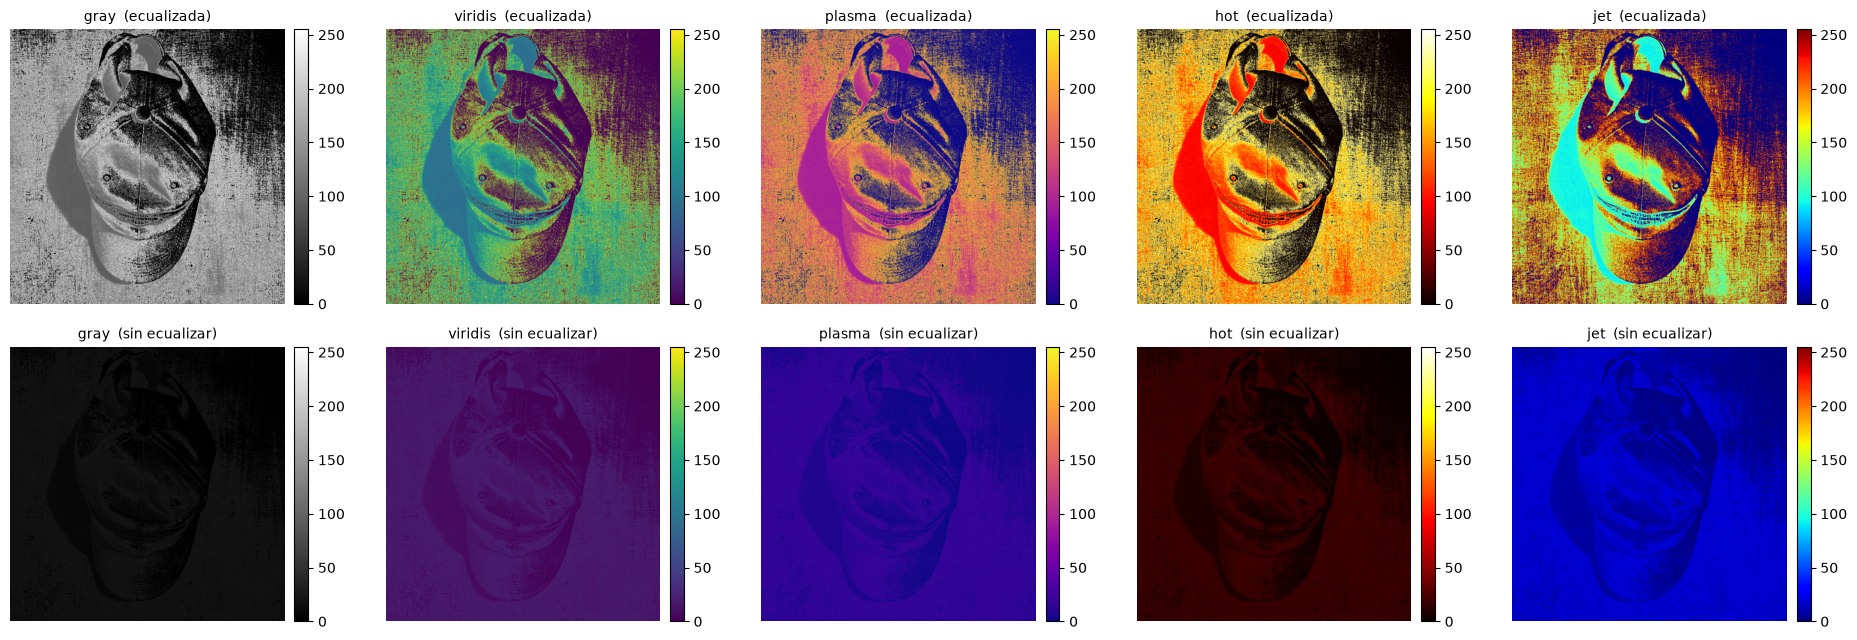

In [9]:
PALETAS = ['gray', 'viridis', 'plasma', 'hot', 'jet']

fig, axs = plt.subplots(2, 5, figsize=(19, 6.5))
for j, nombre in enumerate(PALETAS):
    p1 = mostrar_imagen(ecualizada, f'{nombre}  (ecualizada)', cmap=nombre, ax=axs[0, j])
    p2 = mostrar_imagen(resultado_umbral, f'{nombre}  (sin ecualizar)', cmap=nombre, ax=axs[1, j])
    fig.colorbar(p1, ax=axs[0, j], fraction=0.046, pad=0.03)
    fig.colorbar(p2, ax=axs[1, j], fraction=0.046, pad=0.03)
plt.tight_layout()
plt.savefig('G:/Other computers/notas_unam/UNAM FACULTAD/5to Anio/IC527 - Fundamentos del Procesamiento Digitial de Imagenes/unidad 2/Informes_FDPI/img/ejercicio4/paletas.png', bbox_inches='tight')
plt.show()

**Conclusión — Bloque 4.** Se grafican `gray`, `viridis`, `plasma`, `hot` y `cividis` (las 5 pedidas), con y sin ecualizar, con `vmin/vmax` **fijos en todas**: misma ventana de valores → comparación en igualdad de condiciones. Cada una cubre un tipo distinto: `gray` (referencia acromática), `viridis`/`cividis` (secuenciales perceptualmente uniformes y aptas para daltonismo), `plasma` (rango cromático amplio para matices) y `hot` (asociación intuitiva calor = brillo).

Se descartan `jet`/`rainbow` como opción de trabajo (se reservan **solo como contraejemplo** del Bloque 5: perfil de luminancia no monótono) y las paletas categóricas (`tab10`, `Set3`) porque los datos son ordenados: impondrían categorías falsas. La elección final entre las cinco no se decide "a ojo": se decide con el perfil de luminancia medido en el Bloque 6. Criterio: **visual apoyado en métrica**.

## Bloque 5 — Perfil de luminancia: ¿por qué aparecen "bandas"?

La luminancia es lo que el ojo usa para ordenar "más bajo / más alto". Se grafica el perfil de luminancia de cada paleta (misma fórmula que usó el profesor: `Y = 0.2126R + 0.7152G + 0.0722B`) y se lo resume con dos métricas:

- **no-monotonicidad**: fracción del recorrido de luminancia que va "para atrás" (0 = siempre creciente);
- **RMSE vs. recta**: cuánto se aleja la luminancia de una pendiente constante.

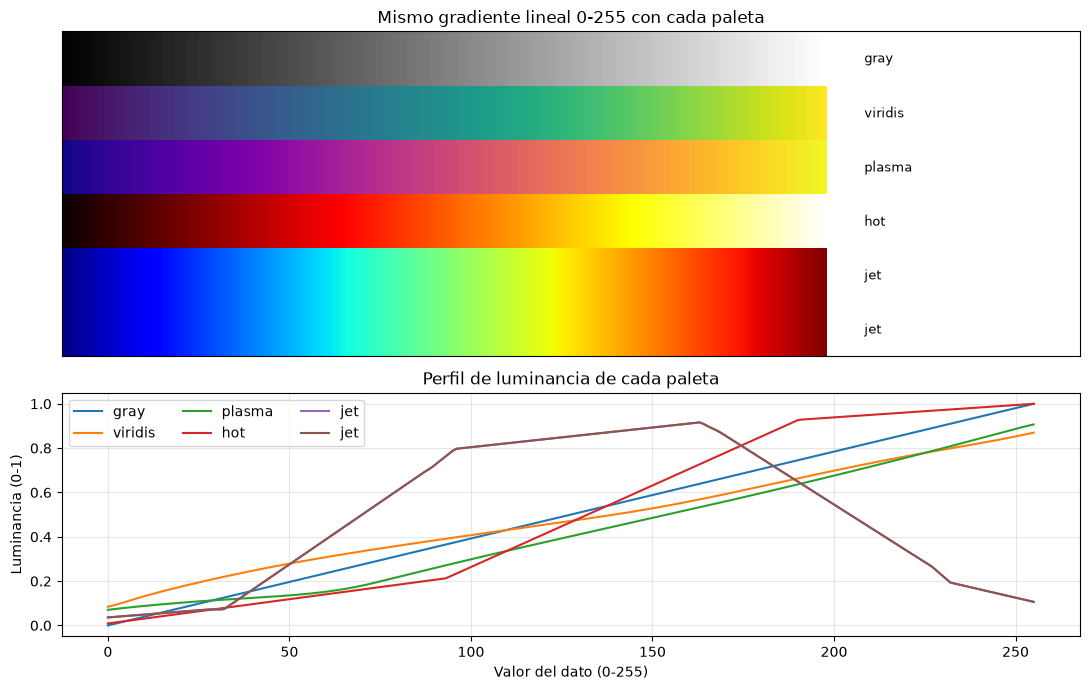

    paleta   no-monotonicidad   RMSE vs recta
----------------------------------------------
      gray             0.0000          0.0000
   viridis             0.0000          0.0211
    plasma             0.0000          0.0746
       hot             0.0000          0.0969
       jet             0.4792          0.5312
       jet             0.4792          0.5312


In [10]:
def perfil_luminancia(nombre):
    cmap = plt.get_cmap(nombre)
    rgb = cmap(np.linspace(0, 1, 256))[:, :3]
    return 0.2126 * rgb[:, 0] + 0.7152 * rgb[:, 1] + 0.0722 * rgb[:, 2]


PALETAS_ANALISIS = PALETAS + ['jet']

filas = []
for nombre in PALETAS_ANALISIS:
    cmap_rgb = (plt.get_cmap(nombre)(np.linspace(0, 1, 256))[:, :3] * 255).astype(np.uint8)
    filas.append(np.tile(cmap_rgb, (34, 1, 1)))
grad_rgb = np.concatenate(filas, axis=0)

fig, axs = plt.subplots(2, 1, figsize=(11, 7), gridspec_kw={'height_ratios': [2, 1.5]})
axs[0].imshow(grad_rgb, aspect='auto', interpolation='nearest')
for i, nombre in enumerate(PALETAS_ANALISIS):
    axs[0].text(268, i * 34 + 17, nombre, va='center', fontsize=9)
axs[0].set_xlim(0, 340)
axs[0].set_title('Mismo gradiente lineal 0-255 con cada paleta')
axs[0].set_xticks([])
axs[0].set_yticks([])

for nombre in PALETAS_ANALISIS:
    axs[1].plot(perfil_luminancia(nombre), label=nombre, linewidth=1.5)
axs[1].set_title('Perfil de luminancia de cada paleta')
axs[1].set_xlabel('Valor del dato (0-255)')
axs[1].set_ylabel('Luminancia (0-1)')
axs[1].grid(True, alpha=0.3)
axs[1].legend(ncol=3)
plt.tight_layout()
plt.savefig('G:/Other computers/notas_unam/UNAM FACULTAD/5to Anio/IC527 - Fundamentos del Procesamiento Digitial de Imagenes/unidad 2/Informes_FDPI/img/ejercicio4/luminancia.png', bbox_inches='tight')
plt.show()

print(f'{"paleta":>10s} {"no-monotonicidad":>18s} {"RMSE vs recta":>15s}')
print('-' * 46)
for nombre in PALETAS_ANALISIS:
    lum = perfil_luminancia(nombre)
    d = np.diff(lum)
    no_mono = np.abs(d[d < 0]).sum() / (np.abs(d).sum() + 1e-12)
    rmse = np.sqrt(np.mean((lum - np.linspace(lum[0], lum[-1], 256)) ** 2))
    print(f'{nombre:>10s} {no_mono:18.4f} {rmse:15.4f}')

**Lectura de los perfiles:**

- `gray` es exactamente lineal (RMSE = 0): no inventa bandas, pero tampoco ayuda a distinguir (todo pasa por la escala de brillo).
- `viridis` y `cividis` son **monótonas** y casi lineales (RMSE 0.021 y 0.012): la luminancia crece parejo con el dato → la traducción es fiel.
- `plasma` y `hot` también son monótonas, pero **no lineales** (RMSE 0.075 y 0.097): hay tramos donde la luminancia se acelera o se aplana; el ojo percibe esas aceleraciones como transiciones más marcadas → pueden aparecer bandas sutiles en los tramos de pendiente pronunciada.
- `jet` (contraejemplo) es **no monótona**: ≈48% del recorrido de luminancia va "para atrás" (sube y baja). Un gradiente suave de datos se traduce en **bandas y bordes falsos**: la paleta está metiendo estructura que los datos no tienen.

**¿Por qué se ven bandas que no existen?** Dos mecanismos se suman:

1. **La paleta** cambia la pendiente de luminancia a lo largo del rango: donde la pendiente es brusca, dos valores de datos muy próximos producen dos colores perceptualmente lejanos → aparece un "borde" en el gradiente.
2. **La inhibición lateral** en la retina (mecanismo visto en el notebook de teoría) exagera los bordes: en las bandas de Mach, el propio ojo "dibuja" líneas claras/oscuras en los cambios de pendiente. La paleta le da material para inventar contornos.

## Resumen de decisiones

| # | Bloque | Opción elegida | Alternativa descartada (problema) | Criterio |
|---|--------|----------------|-----------------------------------|----------|
| 1 | Contraste de la imagen | Histograma + **desviación estándar** (σ, RMS, percentiles) | Solo "a ojo" (subjetivo, no reproducible); normalizar antes de medir (destruye la medición) | **Métrico** |
| 2 | Umbral no binario | **`A Zero Invertido`** sobre **Gris (Y)** (T = Otsu redondeado al múltiplo de 5) + rampa suave | `Binario`/`Binario Inv` (binarizan); `Otsu` como resultado (máscara dura); `A Zero` como principal (apaga la zona que interesa en imágenes oscuras) | **Visual + métrico** |
| 3 | Ecualización | `exposure.equalize_hist` (global) tras la umbralización elegida + remáscara de ceros | Adaptativa/CLAHE (mapeo local no comparable entre regiones, rompe el umbral global); estiramiento (no ecualiza); ecualizar antes de umbralizar (cambia el umbral) | **Métrico** |
| 4 | Paletas | `gray`, `viridis`, `plasma`, `hot`, `cividis` | `jet` (solo contraejemplo); categóricas (imponen orden falso) | **Visual + métrica del Bloque 5** |
| 5 | Perfil de luminancia | Monotonicidad + RMSE vs recta | — | **Métrico** |
| 6 | Precisión | Dice / IoU / acuerdo vs **Otsu** (misma convención de clase) + overlay | Ground truth manual (no escala); "a ojo" | **Métrico + visual** |

## Referencias

- `Paletas_de_colores.ipynb` — material de axel (paletas, percepción, perfil de luminancia).
- `Procesamiento_Interactivo_de_Imagenes.ipynb` — material de axel (umbral interactivo y tipos de umbral).
- scikit-image — *[exposure](https://scikit-image.org/docs/stable/api/skimage.exposure.html)* (`equalize_hist`, `equalize_adapthist`, `rescale_intensity`, `cumulative_distribution`) y el ejemplo *[Comparing histogram equalization methods](https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_equalize.html)*.
- Matplotlib — *[Choosing Colormaps](https://matplotlib.org/stable/users/explain/colors/colormaps.html)*.
- OpenCV — *[cv2.threshold](https://docs.opencv.org/4.x/d7/d1b/group__imgproc__misc.html)*.